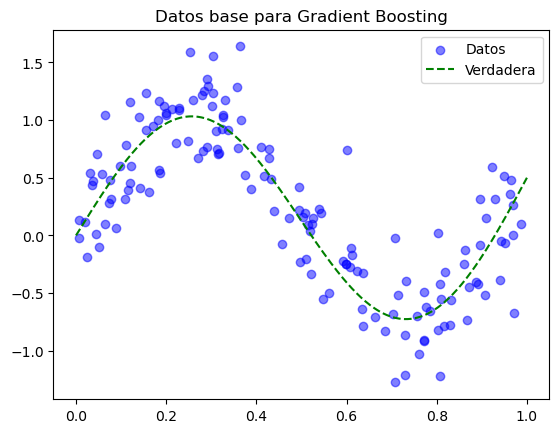

In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Funcion verdadera + ruido
def true_function(x):
    return np.sin(2 * np.pi * x) + 0.5 * x**2

N = 150
x = np.sort(np.random.uniform(0, 1, N))
y = true_function(x) + np.random.normal(0, 0.3, N)

x_test = np.linspace(0, 1, 300)
y_true = true_function(x_test)

plt.scatter(x, y, color='blue', alpha=0.5, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.title('Datos base para Gradient Boosting')
plt.legend()
plt.show()

In [40]:
def stump_fit(x, y, weights=None):
    """
    Árbol stump (depth=1): un solo split.
    Tecnología inversa: encuentra split que minimiza error ponderado (weighted RSS).
    - Si weights=None → pesos uniformes (1/N).
    - Si weights se pasa → usa esos pesos (para boosting, donde errores difíciles pesan más).
    """
    # Inicialización segura de weights (evita UnboundLocalError)
    weights = weights if weights is not None else np.ones(len(y)) / len(y)
    
    best_split = None
    best_rss = np.inf
    best_left_mean = None
    best_right_mean = None
    
    # Probar splits en valores únicos de x
    for split in np.unique(x):
        left = x < split
        right = ~left
        
        # Saltar si una rama queda vacía o muy pequeña
        if np.sum(left) == 0 or np.sum(right) == 0:
            continue
        
        # Media ponderada en cada rama
        mean_left = np.average(y[left], weights=weights[left])
        mean_right = np.average(y[right], weights=weights[right])
        
        # Error ponderado total (weighted RSS)
        rss_left = np.sum(weights[left] * (y[left] - mean_left)**2)
        rss_right = np.sum(weights[right] * (y[right] - mean_right)**2)
        rss_total = rss_left + rss_right
        
        # Guardar el mejor
        if rss_total < best_rss:
            best_rss = rss_total
            best_split = split
            best_left_mean = mean_left
            best_right_mean = mean_right
    
    # Función predictora del stump
    def predict(xi):
        if best_split is None:
            return np.mean(y)  # fallback
        return best_left_mean if xi < best_split else best_right_mean
    
    return predict, best_split

In [41]:
def gradient_boosting(x, y, M=100, learning_rate=0.1, max_depth=1):
    """
    Gradient Boosting simple (regresion).
    Tegnologia inversa: cada iteracion ajusta un stump a los residuos (gradiente negativo)
    """
    models = []
    predictions = np.mean(y) * np.ones(len(y))  # Inicializada con medida

    for m in range(M):
        # Residuos actuales (gradiente negativo de perdida cuadratica)
        residuals = y - predictions

        # Ajusta stump a residuos
        stump, split = stump_fit(x, residuals)
        models.append((stump, split))

        # Actualiza predicciones (shrinkage con learning_rate)
        predictions += learning_rate * np. array([stump(xi) for xi in x])

    def predict_new(x_new):
        pred = np.mean(y) # inicial
        for stump, _ in models:
            pred += learning_rate * stump(x_new)
        return pred

    return predict_new, models    

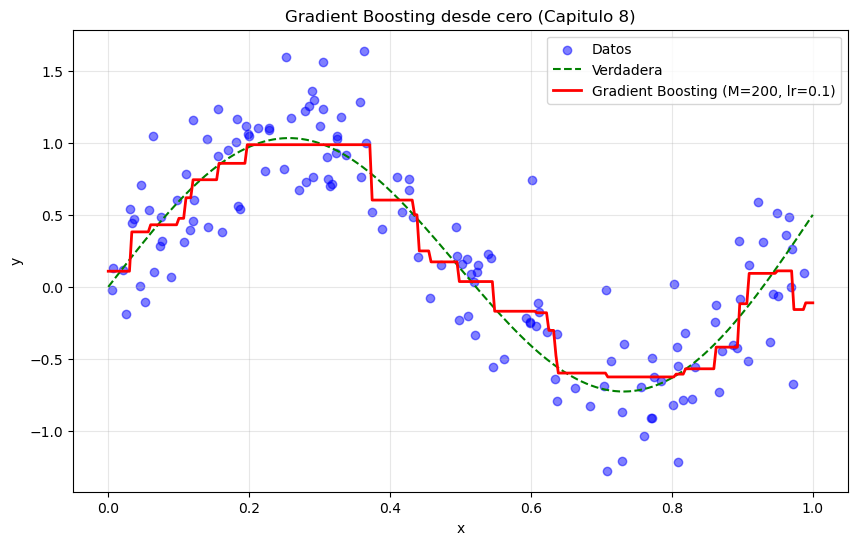

In [42]:
learning_rate = 0.1
M = 200 # numero de interaciones (arboles)

predict_gb, models_gb = gradient_boosting(x, y, M=M, learning_rate=learning_rate)

y_pred_gb = np.array([predict_gb(xi) for xi in x_test])

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.5, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.plot(x_test, y_pred_gb, 'r-', linewidth=2, label=f'Gradient Boosting (M={M}, lr={learning_rate})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Boosting desde cero (Capitulo 8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusiones del Capítulo 8  
(Boosting and Other Ensemble Methods)

- *Gradient Boosting desde cero*:  
  - Construye secuencialmente: cada nuevo árbol (stump) corrige los residuos del anterior.  
  - Pérdida cuadrática → gradiente negativo = residuos.  
  - Learning rate bajo + muchas iteraciones → avanza lento pero estable → evita sobreajuste.

- *Ventajas observadas*:  
  - Gran poder predictivo: la curva roja se acerca muy bien a la verdadera sin seguir ruido excesivo.  
  - Flexibilidad: stumps simples como base → boosting los convierte en modelo potente.  
  - Control de complejidad: M (número de árboles) y learning rate son hiperparámetros clave.

- *Tecnología inversa aplicada*:  
  - Partimos del resultado final (curva roja suave).  
  - Reconstruimos: residuos → stump ponderado → actualización con shrinkage.  
  - Resultado: uno de los métodos más potentes del libro implementado manualmente.

Este capítulo muestra cómo boosting transforma modelos débiles (stumps) en fuertes mediante corrección secuencial de errores 